# Teste — módulo de coleta

**Kernel:** conda `moradinha`  
**Diretório de trabalho:** deve ser `e:/Doutorado/UFABC/moradinha/` (raiz do projeto)

In [1]:
import logging
import sys
from pathlib import Path

# Detecta a raiz do projeto subindo a partir do cwd até encontrar modulo_coleta/
def _encontrar_raiz() -> Path:
    candidato = Path.cwd()
    for _ in range(6):
        if (candidato / "modulo_coleta").is_dir():
            return candidato
        candidato = candidato.parent
    raise FileNotFoundError(
        f"Raiz do projeto não encontrada a partir de '{Path.cwd()}'. "
        "Execute o notebook com o cwd dentro da pasta do projeto."
    )

ROOT = _encontrar_raiz()
print(f"ROOT detectado: {ROOT}")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Logging legível no notebook
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)

print("OK")

ROOT detectado: d:\Doutorado\UFABC\moradinha
OK


In [2]:
import importlib
import modulo_coleta.orquestrador as orchestrator
importlib.reload(orchestrator)
from modulo_coleta.orquestrador import coletar_municipio

## Parâmetros

Edite o código IBGE e os grupos desejados antes de rodar.

In [3]:
CODIGO_IBGE   = "2700300"          # 2701407 Campo Alegre-AL (usado nos testes anteriores)
NOME_PASTA    = "al_arapiraca"  # None = derivado automaticamente via geobr
GRUPOS        = [1, 2, 3, 4, 5]   # remova grupos que não quer coletar
BASE_DIR      = ROOT / "data"
FORCAR        = False              # True = reprocessa mesmo que arquivos já existam

In [ ]:
resultados = coletar_municipio(
    codigo_ibge=CODIGO_IBGE,
    grupos=GRUPOS,
    base_dir=BASE_DIR,
    nome_municipio=NOME_PASTA,
    forcar=FORCAR,
)

14:39:46 [INFO] Município: al_arapiraca (IBGE: 2700300)
14:39:46 [INFO] DuckDB aberto: d:\Doutorado\UFABC\moradinha\data\processed\al_arapiraca\al_arapiraca.duckdb
14:39:46 [INFO] ============================================================
14:39:46 [INFO] Iniciando grupo1_geometrias...
14:39:46 [INFO] [Grupo 1] Limite municipal
14:39:46 [INFO] Baixando limite municipal via geobr (codigo_ibge=2700300)
14:39:48 [INFO] Created 1 records
14:39:51 [INFO] Tabela 'limite_municipal' salva: 1 registros.
14:39:51 [INFO] [Grupo 1] Limite municipal OK
14:39:51 [INFO] [Grupo 1] Setores censitarios
14:39:51 [INFO] Arquivo já existe (pulando download): d:\Doutorado\UFABC\moradinha\data\raw\al_arapiraca\geometria\AL_Malha_Preliminar_2022.gpkg


d:\Doutorado\UFABC\moradinha\modulo_coleta\utils\db_utils.py:140: UserWarning: Geometry column does not contain geometry.
  df_para_salvar["geometry"] = gdf.geometry.apply(lambda geom: geom.wkb)


14:39:52 [INFO] Created 396 records


d:\Doutorado\UFABC\moradinha\modulo_coleta\utils\db_utils.py:140: UserWarning: Geometry column does not contain geometry.
  df_para_salvar["geometry"] = gdf.geometry.apply(lambda geom: geom.wkb)


14:39:54 [INFO] Tabela 'setores_censitarios' salva: 396 registros.
14:39:54 [INFO] [Grupo 1] Setores censitarios OK: 396 setores
14:39:54 [INFO] [Grupo 1] Grade estatistica
14:39:54 [INFO] Arquivo já existe (pulando download): d:\Doutorado\UFABC\moradinha\data\raw\al_arapiraca\geometria\_cache_grade\BR500KM.zip
14:39:54 [INFO] Quadrantes identificados para o municipio: ['ID_58']
14:39:54 [INFO] [Grupo 1] Baixando grade quadrante ID_58
14:39:54 [INFO] Arquivo já existe (pulando download): d:\Doutorado\UFABC\moradinha\data\raw\al_arapiraca\geometria\_cache_grade\grade_id58.zip
14:39:59 [INFO] Created 4,940 records
14:40:01 [INFO] Tabela 'grade_estatistica' salva: 4940 registros.
14:40:01 [INFO] [Grupo 1] Grade estatistica OK: 4940 celulas
14:40:01 [INFO] [Grupo 1] Areas de ponderacao
14:40:01 [INFO] Baixando areas de ponderacao via geobr (codigo_ibge=2700300)


...

d:\Doutorado\UFABC\moradinha\modulo_coleta\utils\db_utils.py:140: UserWarning: Geometry column does not contain geometry.
  df_para_salvar["geometry"] = gdf.geometry.apply(lambda geom: geom.wkb)


14:41:27 [INFO] Tabela 'eixos_osm' salva: 27153 registros.
14:41:27 [INFO] [Grupo 3] Eixos OSM OK: 27153 arestas
14:41:27 [INFO] Grupo 3 finalizado — status: ok
14:41:27 [INFO] ============================================================
14:41:27 [INFO] Iniciando grupo4_luminosidade...
14:41:27 [INFO] Ano inferido do nome do tile: 2022
14:41:27 [INFO] TIF recortado já existe (viirs_2022_recortado.tif) — pulando clip. Use forcar=True para reclacular.
14:41:27 [INFO] [Grupo 4] Calculando zonal stats por setor censitário...
14:41:27 [INFO] Tabela 'setores_censitarios' lida do DuckDB: 396 feições.
14:41:27 [WARNING] CPLE_AppDefined in PROJ: proj_create_from_database: C:\Users\User\anaconda3\envs\moradinha\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.
14:41:27 [WARNING] CPLE_AppDefined in PROJ: proj_create_from_name: C:\Users\User\anaconda3\envs\moradinha\Library\share\proj\proj.db contains D

KeyboardInterrupt: 

Exception ignored in: 'rasterio._err.log_error'
Traceback (most recent call last):
  File "c:\Users\User\anaconda3\envs\moradinha\Lib\logging\__init__.py", line 1575, in log
    def log(self, level, msg, *args, **kwargs):
KeyboardInterrupt: 


14:41:31 [WARNING] CPLE_AppDefined:PROJ: proj_create_from_name: C:\Users\User\anaconda3\envs\moradinha\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.
14:41:31 [WARNING] CPLE_AppDefined:PROJ: proj_create_from_database: C:\Users\User\anaconda3\envs\moradinha\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.
14:41:31 [WARNING] CPLE_AppDefined:PROJ: proj_create_from_name: C:\Users\User\anaconda3\envs\moradinha\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.
14:41:31 [WARNING] CPLE_AppDefined:PROJ: proj_create_from_database: C:\Users\User\anaconda3\envs\moradinha\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installati

## Resumo dos resultados

In [ ]:
from modulo_coleta.orquestrador import GRUPOS_DISPONIVEIS

for grupo, res in resultados.items():
    if grupo in ("mapa", "fig"):
        continue
    nome  = GRUPOS_DISPONIVEIS.get(grupo, f"grupo{grupo}")
    status = res.get("status", "?")
    camadas = res.get("camadas", [])
    msg    = res.get("mensagem", "")
    icone  = "✅" if status == "ok" else ("⏭️" if status == "pulado" else "❌")
    print(f"{icone} Grupo {grupo} ({nome}): {status}")
    if camadas:
        print(f"   camadas: {camadas}")
    if status != "ok":
        print(f"   msg: {msg}")

✅ Grupo 1 (grupo1_geometrias): ok
   camadas: ['limite_municipal', 'setores_censitarios', 'grade_estatistica', 'areas_ponderacao']
✅ Grupo 2 (grupo2_censo): ok
   camadas: ['censo_domicilio01', 'censo_domicilio02', 'censo_responsavel01']
✅ Grupo 3 (grupo3_logradouros): ok
   camadas: ['enderecos_cnefe', 'faces_logradouro', 'eixos_osm']
✅ Grupo 4 (grupo4_luminosidade): ok
   camadas: ['luminosidade_2022', 'luminosidade_2022_grade200']
❌ Grupo 5 (grupo5_pnadc): erro
   msg: Script R falhou (código 3236495362).
Verifique o log acima.
Causas comuns:
  - Pacotes R ausentes (PNADcIBGE, survey, geobr, arrow)
  - Sem conexão com a internet
  - Município sem área de ponderação no geobr


## Mapa de coleta

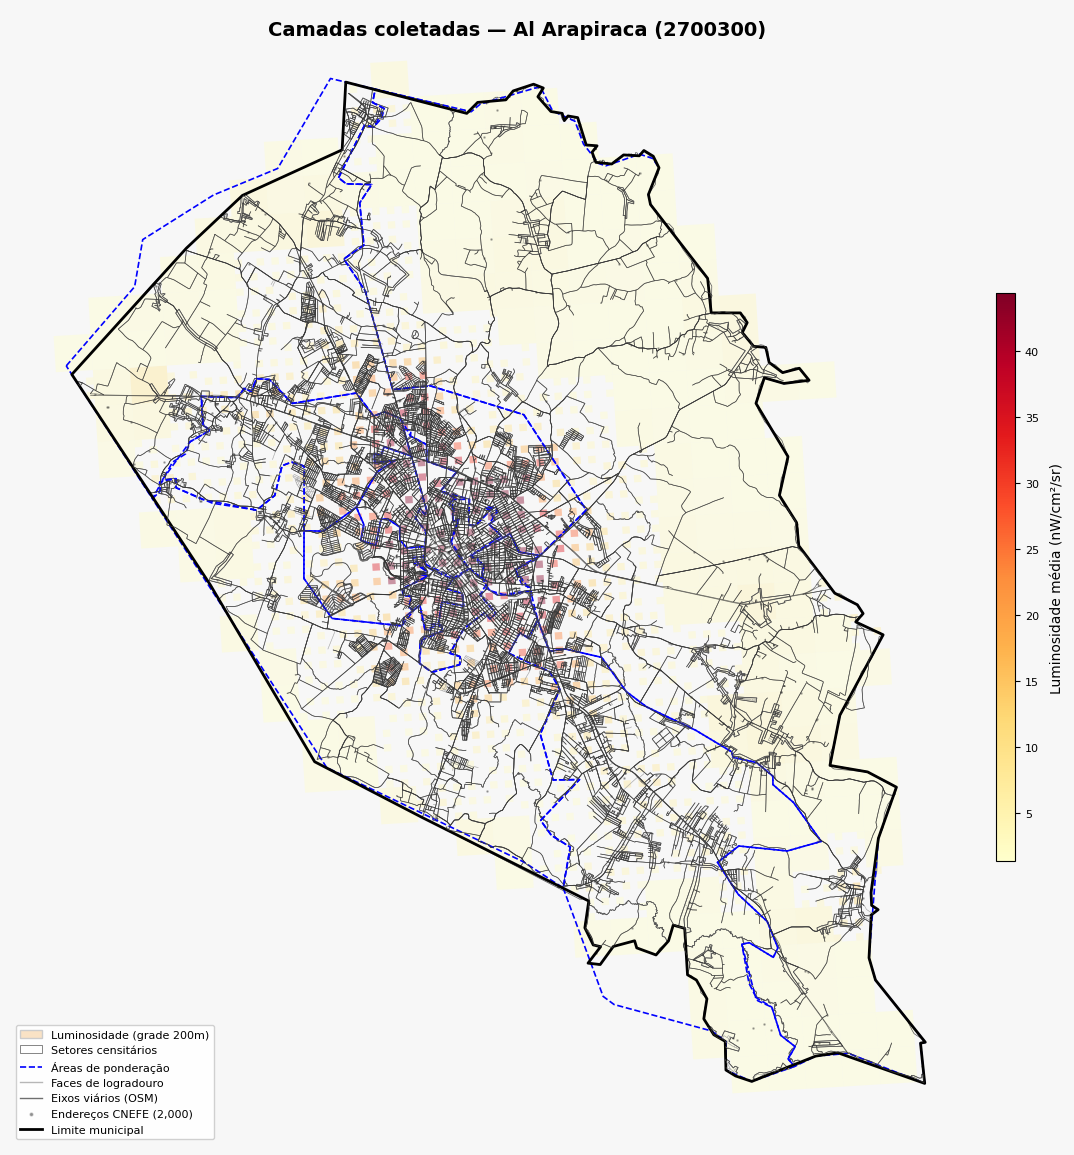

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

fig = resultados.get("fig")
if fig is not None:
    display(fig)
    plt.close(fig)
else:
    print("Mapa não gerado.")

## Inspecionar o DuckDB

Célula opcional para checar as tabelas geradas.

In [ ]:
from modulo_coleta.utils.db_utils import abrir_conexao, listar_tabelas

db_path = BASE_DIR / "processed" / NOME_PASTA / f"{NOME_PASTA}.duckdb"
conn = abrir_conexao(db_path)
tabelas = listar_tabelas(conn)
print(f"Tabelas no banco ({NOME_PASTA}):")
for t in tabelas:
    n = conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"  {t}: {n} registros")
conn.close()

13:42:16 [INFO] DuckDB aberto: d:\Doutorado\UFABC\moradinha\data\processed\al_arapiraca\al_arapiraca.duckdb
Tabelas no banco (al_arapiraca):
  areas_ponderacao: 12 registros
  censo_domicilio01: 426 registros
  censo_domicilio02: 426 registros
  censo_responsavel01: 426 registros
  eixos_osm: 27153 registros
  enderecos_cnefe: 120326 registros
  faces_logradouro: 17460 registros
  grade_estatistica: 4940 registros
  info_municipio: 1 registros
  limite_municipal: 1 registros
  limite_municipal_teste: 1 registros
  luminosidade_2022: 396 registros
  luminosidade_2022_grade200: 4940 registros
  setores_censitarios: 396 registros
